# 03 — UK Airport Passenger Demand Forecasting

## Purpose

This notebook develops and evaluates time-series models for monthly UK airport passenger demand.

## Objectives

- load and validate the forecasting dataset prepared in Notebook 2;
- use a chronological training and test split;
- establish a seasonal-naive baseline;
- build Holt-Winters forecasting models;
- evaluate forecasts using MAE, RMSE and MAPE;
- compare national and airport-level forecasting performance;
- examine the effect of the COVID-19 disruption;
- export model results for the final business analysis.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
)

from statsmodels.tsa.holtwinters import ExponentialSmoothing

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 1. Load the forecasting data

The dataset contains monthly passenger-demand series for the UK total and ten major airports. It was prepared and exported by Notebook 2.

In [2]:
current_folder = Path.cwd()

if (current_folder / "data").exists():
    project_root = current_folder
elif (current_folder.parent / "data").exists():
    project_root = current_folder.parent
else:
    raise FileNotFoundError(
        "The project data folder could not be located."
    )

data_path = (
    project_root
    / "data"
    / "interim"
    / "forecasting_passenger_series.csv"
)

forecasting_data = pd.read_csv(
    data_path,
    parse_dates=["period_date"],
)

print(f"Data file: {data_path}")
print(f"Rows: {len(forecasting_data):,}")
print(f"Series: {forecasting_data['series_name'].nunique()}")
print(
    "Date range:",
    forecasting_data["period_date"].min().strftime("%B %Y"),
    "to",
    forecasting_data["period_date"].max().strftime("%B %Y"),
)

display(forecasting_data.head())

Data file: /Users/dafyddjones/projects/uk-aviation-demand-punctuality/data/interim/forecasting_passenger_series.csv
Rows: 1,452
Series: 11
Date range: January 2015 to December 2025


,period_date,series_name,terminal_passengers
0,2015-01-01,BELFAST INTERNATIONAL,237819
1,2015-02-01,BELFAST INTERNATIONAL,273539
2,2015-03-01,BELFAST INTERNATIONAL,331487
3,2015-04-01,BELFAST INTERNATIONAL,340519
4,2015-05-01,BELFAST INTERNATIONAL,393138


## 2. Validate the forecasting dataset

Before modelling, the dataset is checked for missing values, duplicated months, negative passenger counts and incomplete time series.

In [3]:
validation_summary = {
    "rows": len(forecasting_data),
    "series": forecasting_data["series_name"].nunique(),
    "months": forecasting_data["period_date"].nunique(),
    "missing_dates": forecasting_data["period_date"].isna().sum(),
    "missing_series_names": forecasting_data["series_name"].isna().sum(),
    "missing_passenger_values": (
        forecasting_data["terminal_passengers"].isna().sum()
    ),
    "duplicate_series_months": forecasting_data.duplicated(
        subset=["series_name", "period_date"]
    ).sum(),
    "negative_passenger_values": (
        forecasting_data["terminal_passengers"] < 0
    ).sum(),
}

for check, result in validation_summary.items():
    print(f"{check}: {result}")

missing_rows = forecasting_data.loc[
    forecasting_data["terminal_passengers"].isna()
]

display(missing_rows)

rows: 1452
series: 11
months: 132
missing_dates: 0
missing_series_names: 0
missing_passenger_values: 0
duplicate_series_months: 0
negative_passenger_values: 0


,period_date,series_name,terminal_passengers


In [4]:
series_coverage = (
    forecasting_data.groupby("series_name")
    .agg(
        observations=("period_date", "size"),
        first_month=("period_date", "min"),
        last_month=("period_date", "max"),
        missing_values=(
            "terminal_passengers",
            lambda values: values.isna().sum(),
        ),
    )
    .reset_index()
)

series_coverage["complete_history"] = (
    (series_coverage["observations"] == 132)
    & (series_coverage["first_month"] == pd.Timestamp("2015-01-01"))
    & (series_coverage["last_month"] == pd.Timestamp("2025-12-01"))
    & (series_coverage["missing_values"] == 0)
)

display(series_coverage)
print(
    "\nAll series have complete histories:",
    series_coverage["complete_history"].all(),
)

,series_name,observations,first_month,last_month,missing_values,complete_history
0,BELFAST INTERNATIONAL,132,2015-01-01,2025-12-01,0,True
1,BIRMINGHAM,132,2015-01-01,2025-12-01,0,True
2,BRISTOL,132,2015-01-01,2025-12-01,0,True
3,EDINBURGH,132,2015-01-01,2025-12-01,0,True
4,GATWICK,132,2015-01-01,2025-12-01,0,True
5,GLASGOW,132,2015-01-01,2025-12-01,0,True
6,HEATHROW,132,2015-01-01,2025-12-01,0,True
7,LUTON,132,2015-01-01,2025-12-01,0,True
8,MANCHESTER,132,2015-01-01,2025-12-01,0,True
9,STANSTED,132,2015-01-01,2025-12-01,0,True



All series have complete histories: True


## 3. Create a chronological training and test split

Time-series data must remain in date order. Random splitting would allow future observations to influence models trained on the past.

Data from January 2015 to December 2024 is used for training. The final 12 months, January to December 2025, are held out for testing.

In [5]:
test_start = pd.Timestamp("2025-01-01")

train_data = forecasting_data.loc[
    forecasting_data["period_date"] < test_start
].copy()

test_data = forecasting_data.loc[
    forecasting_data["period_date"] >= test_start
].copy()

split_summary = (
    forecasting_data.assign(
        dataset=np.where(
            forecasting_data["period_date"] < test_start,
            "Training",
            "Test",
        )
    )
    .groupby(["series_name", "dataset"])
    .agg(
        observations=("period_date", "size"),
        first_month=("period_date", "min"),
        last_month=("period_date", "max"),
    )
    .reset_index()
)

print(f"Training rows: {len(train_data):,}")
print(f"Test rows: {len(test_data):,}")
print(
    "Shared dates between training and test:",
    len(
        set(train_data["period_date"])
        & set(test_data["period_date"])
    ),
)

display(split_summary)

Training rows: 1,320
Test rows: 132
Shared dates between training and test: 0


,series_name,dataset,observations,first_month,last_month
0,BELFAST INTERNATIONAL,Test,12,2025-01-01,2025-12-01
1,BELFAST INTERNATIONAL,Training,120,2015-01-01,2024-12-01
2,BIRMINGHAM,Test,12,2025-01-01,2025-12-01
3,BIRMINGHAM,Training,120,2015-01-01,2024-12-01
4,BRISTOL,Test,12,2025-01-01,2025-12-01
5,BRISTOL,Training,120,2015-01-01,2024-12-01
6,EDINBURGH,Test,12,2025-01-01,2025-12-01
7,EDINBURGH,Training,120,2015-01-01,2024-12-01
8,GATWICK,Test,12,2025-01-01,2025-12-01
9,GATWICK,Training,120,2015-01-01,2024-12-01


## 4. Seasonal-naive baseline

A seasonal-naive forecast assumes that each month will have the same passenger demand as the corresponding month one year earlier.

For example, the forecast for August 2025 is the observed passenger count from August 2024. This is a useful baseline because airport demand has a strong annual seasonal pattern. More advanced models should improve upon it.

In [6]:
seasonal_history = train_data[
    [
        "period_date",
        "series_name",
        "terminal_passengers",
    ]
].copy()

seasonal_history["period_date"] = (
    seasonal_history["period_date"]
    + pd.DateOffset(years=1)
)

seasonal_history = seasonal_history.rename(
    columns={
        "terminal_passengers":
        "seasonal_naive_prediction"
    }
)

seasonal_naive_results = test_data[
    [
        "period_date",
        "series_name",
        "terminal_passengers",
    ]
].merge(
    seasonal_history,
    on=["period_date", "series_name"],
    how="left",
    validate="one_to_one",
)

seasonal_naive_results = seasonal_naive_results.rename(
    columns={
        "terminal_passengers": "actual_passengers"
    }
)

print(
    "Forecast rows:",
    len(seasonal_naive_results),
)
print(
    "Missing forecasts:",
    seasonal_naive_results[
        "seasonal_naive_prediction"
    ].isna().sum(),
)

display(seasonal_naive_results.head(12))

Forecast rows: 132
Missing forecasts: 0


,period_date,series_name,actual_passengers,seasonal_naive_prediction
0,2025-01-01,BELFAST INTERNATIONAL,390629,364664
1,2025-02-01,BELFAST INTERNATIONAL,465109,451515
2,2025-03-01,BELFAST INTERNATIONAL,507361,509163
3,2025-04-01,BELFAST INTERNATIONAL,552566,555835
4,2025-05-01,BELFAST INTERNATIONAL,599543,631539
5,2025-06-01,BELFAST INTERNATIONAL,640102,625270
6,2025-07-01,BELFAST INTERNATIONAL,694251,709170
7,2025-08-01,BELFAST INTERNATIONAL,695823,707906
8,2025-09-01,BELFAST INTERNATIONAL,594984,618734
9,2025-10-01,BELFAST INTERNATIONAL,595468,607728


## 5. Evaluate the baseline forecast

Three metrics are used:

- **MAE (Mean Absolute Error):** the average number of passengers by which the forecasts are wrong.
- **RMSE (Root Mean Squared Error):** similar to MAE, but gives greater weight to large errors.
- **MAPE (Mean Absolute Percentage Error):** the average error expressed as a percentage of actual demand.

Lower values indicate better forecasting performance. MAPE is particularly useful when comparing airports of different sizes.

In [7]:
def calculate_forecast_metrics(
    actual,
    predicted,
):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(
        mean_squared_error(actual, predicted)
    )

    non_zero = actual != 0
    mape = np.mean(
        np.abs(
            (
                actual[non_zero]
                - predicted[non_zero]
            )
            / actual[non_zero]
        )
    ) * 100

    return pd.Series(
        {
            "MAE": mae,
            "RMSE": rmse,
            "MAPE": mape,
        }
    )


seasonal_naive_metrics = (
    seasonal_naive_results.groupby("series_name")
    .apply(
        lambda group: calculate_forecast_metrics(
            group["actual_passengers"],
            group["seasonal_naive_prediction"],
        ),
        include_groups=False,
    )
    .reset_index()
)

seasonal_naive_metrics["model"] = (
    "Seasonal naive"
)

seasonal_naive_metrics = (
    seasonal_naive_metrics[
        [
            "series_name",
            "model",
            "MAE",
            "RMSE",
            "MAPE",
        ]
    ]
    .sort_values("MAPE")
    .reset_index(drop=True)
)

display(
    seasonal_naive_metrics.style.format(
        {
            "MAE": "{:,.0f}",
            "RMSE": "{:,.0f}",
            "MAPE": "{:.2f}%",
        }
    )
)

,series_name,model,MAE,RMSE,MAPE
0,STANSTED,Seasonal naive,"39,948","53,454",1.80%
1,UK TOTAL,Seasonal naive,"579,225","667,522",2.40%
2,HEATHROW,Seasonal naive,"161,671","222,162",2.42%
3,GATWICK,Seasonal naive,"82,988","92,585",2.45%
4,BELFAST INTERNATIONAL,Seasonal naive,"13,951","16,700",2.57%
5,GLASGOW,Seasonal naive,"16,445","20,169",2.72%
6,BRISTOL,Seasonal naive,"25,337","30,866",3.25%
7,MANCHESTER,Seasonal naive,"108,811","118,608",4.31%
8,LUTON,Seasonal naive,"69,319","73,353",4.86%
9,BIRMINGHAM,Seasonal naive,"67,725","72,232",6.00%


## 6. Holt-Winters exponential smoothing

Holt-Winters modelling estimates three components of a time series:

- **level:** the current underlying volume of passengers;
- **trend:** the longer-term direction of demand;
- **seasonality:** the recurring monthly pattern.

An additive, damped trend is used to prevent the long-term trend from increasing indefinitely. Multiplicative seasonality allows the size of the seasonal variation to change with passenger volume.

In [8]:
minimum_values = (
    train_data.groupby("series_name")[
        "terminal_passengers"
    ]
    .min()
    .sort_values()
)

display(minimum_values)

series_name
BELFAST INTERNATIONAL         0
MANCHESTER                    0
BRISTOL                     357
GLASGOW                    2790
BIRMINGHAM                 4768
EDINBURGH                  5381
GATWICK                    7031
STANSTED                  13692
LUTON                     14183
HEATHROW                 206600
UK TOTAL                 334032
Name: terminal_passengers, dtype: int64

In [9]:
holt_winters_forecasts = []

for series_name in sorted(
    forecasting_data["series_name"].unique()
):
    training_series = (
        train_data.loc[
            train_data["series_name"] == series_name,
            ["period_date", "terminal_passengers"],
        ]
        .sort_values("period_date")
        .set_index("period_date")[
            "terminal_passengers"
        ]
        .asfreq("MS")
    )

    model = ExponentialSmoothing(
        training_series,
        trend="add",
        damped_trend=True,
        seasonal="add",
        seasonal_periods=12,
        initialization_method="estimated",
    )

    fitted_model = model.fit(
        optimized=True,
        use_brute=True,
    )

    forecast = fitted_model.forecast(12)

    series_forecast = pd.DataFrame(
        {
            "period_date": forecast.index,
            "series_name": series_name,
            "holt_winters_prediction": forecast.values,
        }
    )

    holt_winters_forecasts.append(series_forecast)


holt_winters_results = pd.concat(
    holt_winters_forecasts,
    ignore_index=True,
)

holt_winters_results = test_data[
    [
        "period_date",
        "series_name",
        "terminal_passengers",
    ]
].merge(
    holt_winters_results,
    on=["period_date", "series_name"],
    how="left",
    validate="one_to_one",
)

holt_winters_results = holt_winters_results.rename(
    columns={
        "terminal_passengers": "actual_passengers"
    }
)

print(
    "Forecast rows:",
    len(holt_winters_results),
)
print(
    "Missing forecasts:",
    holt_winters_results[
        "holt_winters_prediction"
    ].isna().sum(),
)

display(holt_winters_results.head(12))

Forecast rows: 132
Missing forecasts: 0


,period_date,series_name,actual_passengers,holt_winters_prediction
0,2025-01-01,BELFAST INTERNATIONAL,390629,445353.571110
1,2025-02-01,BELFAST INTERNATIONAL,465109,485796.172589
2,2025-03-01,BELFAST INTERNATIONAL,507361,525088.059933
3,2025-04-01,BELFAST INTERNATIONAL,552566,560833.341439
4,2025-05-01,BELFAST INTERNATIONAL,599543,614159.375046
5,2025-06-01,BELFAST INTERNATIONAL,640102,641932.734573
6,2025-07-01,BELFAST INTERNATIONAL,694251,686534.814480
7,2025-08-01,BELFAST INTERNATIONAL,695823,687770.716493
8,2025-09-01,BELFAST INTERNATIONAL,594984,614608.944868
9,2025-10-01,BELFAST INTERNATIONAL,595468,588393.257537


## 7. Compare forecasting models

Holt-Winters is compared with the seasonal-naive baseline for every series. The model with the lower MAPE is treated as the better-performing model because MAPE permits comparison across airports of different sizes.

In [10]:
holt_winters_metrics = (
    holt_winters_results.groupby("series_name")
    .apply(
        lambda group: calculate_forecast_metrics(
            group["actual_passengers"],
            group["holt_winters_prediction"],
        ),
        include_groups=False,
    )
    .reset_index()
)

holt_winters_metrics["model"] = "Holt-Winters"

holt_winters_metrics = holt_winters_metrics[
    [
        "series_name",
        "model",
        "MAE",
        "RMSE",
        "MAPE",
    ]
]

model_metrics = (
    pd.concat(
        [
            seasonal_naive_metrics,
            holt_winters_metrics,
        ],
        ignore_index=True,
    )
    .sort_values(["series_name", "MAPE"])
    .reset_index(drop=True)
)

display(
    model_metrics.style.format(
        {
            "MAE": "{:,.0f}",
            "RMSE": "{:,.0f}",
            "MAPE": "{:.2f}%",
        }
    )
)

,series_name,model,MAE,RMSE,MAPE
0,BELFAST INTERNATIONAL,Seasonal naive,"13,951","16,700",2.57%
1,BELFAST INTERNATIONAL,Holt-Winters,"17,731","22,518",3.68%
2,BIRMINGHAM,Holt-Winters,"44,226","53,675",4.59%
3,BIRMINGHAM,Seasonal naive,"67,725","72,232",6.00%
4,BRISTOL,Seasonal naive,"25,337","30,866",3.25%
5,BRISTOL,Holt-Winters,"85,651","97,606",8.84%
6,EDINBURGH,Holt-Winters,"59,218","75,710",5.05%
7,EDINBURGH,Seasonal naive,"99,142","104,490",6.93%
8,GATWICK,Seasonal naive,"82,988","92,585",2.45%
9,GATWICK,Holt-Winters,"634,584","646,997",18.16%


In [11]:
model_comparison = (
    model_metrics.pivot(
        index="series_name",
        columns="model",
        values="MAPE",
    )
    .reset_index()
)

model_comparison.columns.name = None

model_comparison["best_model"] = np.where(
    model_comparison["Holt-Winters"]
    < model_comparison["Seasonal naive"],
    "Holt-Winters",
    "Seasonal naive",
)

model_comparison["best_MAPE"] = model_comparison[
    [
        "Holt-Winters",
        "Seasonal naive",
    ]
].min(axis=1)

model_comparison[
    "holt_winters_improvement_percentage_points"
] = (
    model_comparison["Seasonal naive"]
    - model_comparison["Holt-Winters"]
)

model_comparison = (
    model_comparison.sort_values("best_MAPE")
    .reset_index(drop=True)
)

display(
    model_comparison.style.format(
        {
            "Holt-Winters": "{:.2f}%",
            "Seasonal naive": "{:.2f}%",
            "best_MAPE": "{:.2f}%",
            "holt_winters_improvement_percentage_points":
                "{:+.2f}",
        }
    )
)

print("\nBest-model counts:")
print(
    model_comparison["best_model"].value_counts()
)

,series_name,Holt-Winters,Seasonal naive,best_model,best_MAPE,holt_winters_improvement_percentage_points
0,STANSTED,6.41%,1.80%,Seasonal naive,1.80%,-4.61
1,UK TOTAL,12.51%,2.40%,Seasonal naive,2.40%,-10.11
2,HEATHROW,12.63%,2.42%,Seasonal naive,2.42%,-10.21
3,GATWICK,18.16%,2.45%,Seasonal naive,2.45%,-15.71
4,BELFAST INTERNATIONAL,3.68%,2.57%,Seasonal naive,2.57%,-1.12
5,GLASGOW,20.99%,2.72%,Seasonal naive,2.72%,-18.27
6,BRISTOL,8.84%,3.25%,Seasonal naive,3.25%,-5.58
7,MANCHESTER,3.91%,4.31%,Holt-Winters,3.91%,+0.40
8,BIRMINGHAM,4.59%,6.00%,Holt-Winters,4.59%,+1.42
9,LUTON,9.38%,4.86%,Seasonal naive,4.86%,-4.52



Best-model counts:
best_model
Seasonal naive    8
Holt-Winters      3
Name: count, dtype: int64


## 8. Visualise national forecast performance

The UK-wide forecasts are compared with actual passenger demand during 2025. The chart includes recent historical demand to show the seasonal pattern leading into the test period.

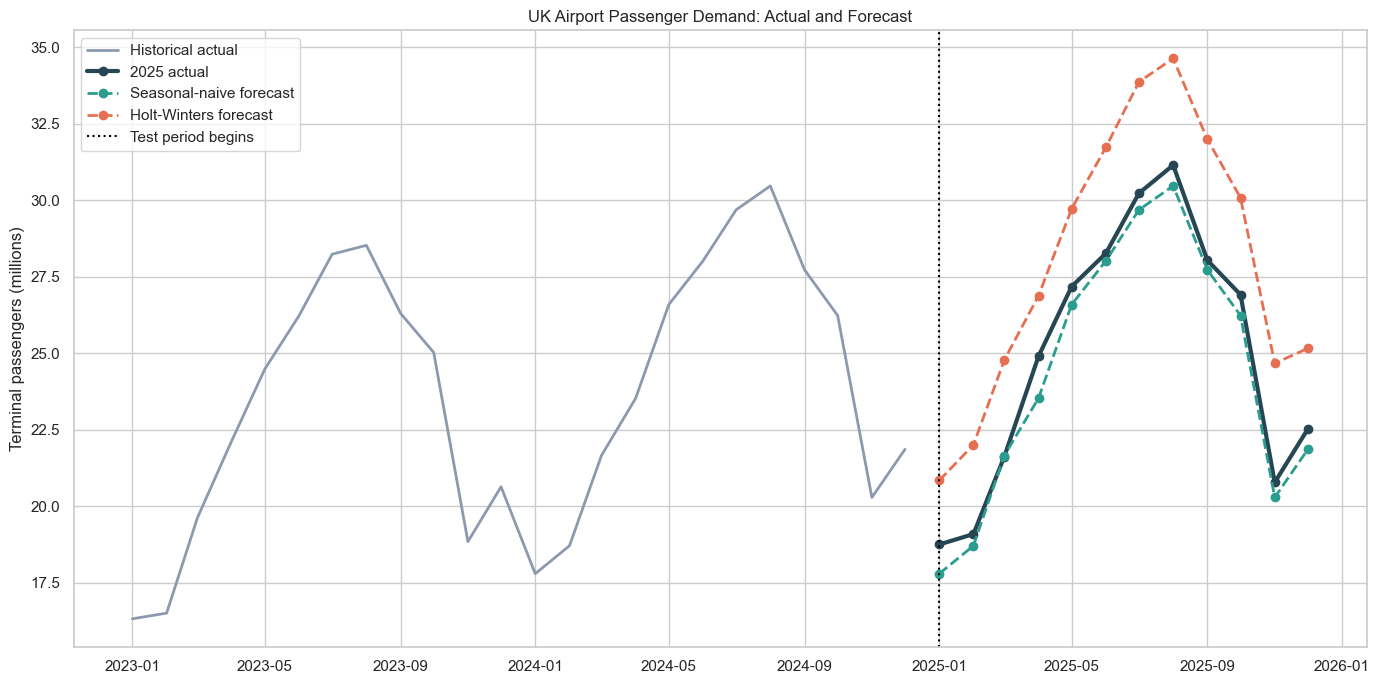

In [12]:
uk_history = forecasting_data.loc[
    (
        forecasting_data["series_name"]
        == "UK TOTAL"
    )
    & (
        forecasting_data["period_date"]
        >= "2023-01-01"
    )
    & (
        forecasting_data["period_date"]
        < "2025-01-01"
    )
].copy()

uk_forecast_comparison = (
    seasonal_naive_results.loc[
        seasonal_naive_results["series_name"]
        == "UK TOTAL"
    ]
    .merge(
        holt_winters_results[
            [
                "period_date",
                "series_name",
                "holt_winters_prediction",
            ]
        ],
        on=["period_date", "series_name"],
        how="left",
        validate="one_to_one",
    )
)

plt.figure(figsize=(14, 7))

plt.plot(
    uk_history["period_date"],
    uk_history["terminal_passengers"] / 1_000_000,
    color="#8d99ae",
    linewidth=2,
    label="Historical actual",
)

plt.plot(
    uk_forecast_comparison["period_date"],
    uk_forecast_comparison["actual_passengers"]
    / 1_000_000,
    color="#264653",
    linewidth=3,
    marker="o",
    label="2025 actual",
)

plt.plot(
    uk_forecast_comparison["period_date"],
    uk_forecast_comparison[
        "seasonal_naive_prediction"
    ] / 1_000_000,
    color="#2a9d8f",
    linewidth=2,
    linestyle="--",
    marker="o",
    label="Seasonal-naive forecast",
)

plt.plot(
    uk_forecast_comparison["period_date"],
    uk_forecast_comparison[
        "holt_winters_prediction"
    ] / 1_000_000,
    color="#e76f51",
    linewidth=2,
    linestyle="--",
    marker="o",
    label="Holt-Winters forecast",
)

plt.axvline(
    pd.Timestamp("2025-01-01"),
    color="black",
    linestyle=":",
    label="Test period begins",
)

plt.title(
    "UK Airport Passenger Demand: Actual and Forecast"
)
plt.xlabel("")
plt.ylabel("Terminal passengers (millions)")
plt.legend()
plt.tight_layout()
plt.show()

### National forecast findings

Both models reproduced the expected seasonal pattern, with demand increasing towards the summer peak and declining during autumn and winter.

The seasonal-naive forecast remained close to actual demand throughout 2025 and achieved a MAPE of 2.40%. Holt-Winters consistently overestimated passenger demand and achieved a substantially higher MAPE of 12.51%.

The Holt-Winters model appears to have interpreted part of the rapid post-COVID recovery as a continuing underlying trend. By 2025, however, national passenger demand had largely returned to its previous growth pattern. This caused the model to project passenger volumes above those actually recorded.

## 9. Effect of the COVID-19 disruption

A rolling seasonal-naive backtest is used to show how forecast accuracy changed over time. For every month from 2016 onwards, demand is predicted using the corresponding month one year earlier.

This allows normal years, the COVID-19 disruption and the subsequent recovery period to be compared consistently.

In [13]:
uk_backtest = (
    forecasting_data.loc[
        forecasting_data["series_name"] == "UK TOTAL",
        [
            "period_date",
            "terminal_passengers",
        ],
    ]
    .sort_values("period_date")
    .reset_index(drop=True)
)

uk_backtest["seasonal_naive_prediction"] = (
    uk_backtest["terminal_passengers"].shift(12)
)

uk_backtest = (
    uk_backtest.dropna(
        subset=["seasonal_naive_prediction"]
    )
    .copy()
)

uk_backtest["year"] = (
    uk_backtest["period_date"].dt.year
)

annual_backtest_metrics = (
    uk_backtest.groupby("year")
    .apply(
        lambda group: calculate_forecast_metrics(
            group["terminal_passengers"],
            group["seasonal_naive_prediction"],
        ),
        include_groups=False,
    )
    .reset_index()
)

display(
    annual_backtest_metrics.style.format(
        {
            "MAE": "{:,.0f}",
            "RMSE": "{:,.0f}",
            "MAPE": "{:.2f}%",
        }
    )
)

,year,MAE,RMSE,MAPE
0,2016,"1,417,688","1,452,530",6.49%
1,2017,"1,511,665","1,844,870",6.36%
2,2018,"617,860","709,183",2.53%
3,2019,"501,482","577,772",2.18%
4,2020,"18,594,198","20,750,398",1844.55%
5,2021,"6,679,156","8,756,465",390.58%
6,2022,"13,116,287","13,939,248",72.55%
7,2023,"4,251,112","4,641,773",20.49%
8,2024,"1,639,772","1,674,197",6.95%
9,2025,"579,225","667,522",2.40%


### COVID-19 backtest findings

The seasonal-naive model performed reasonably well before the disruption, with MAPE falling to 2.18% in 2019.

Forecast accuracy collapsed in 2020 because historical seasonal patterns could not anticipate the sudden shutdown of aviation. MAPE reached 1,844.55%, partly because percentage errors become extremely large when actual passenger volumes are close to zero.

Forecasting remained difficult during the uneven recovery. The model underestimated 2021 and 2022 demand because it used the severely depressed preceding years as its baseline. Accuracy subsequently improved as the market stabilised, reaching 6.95% in 2024 and 2.40% in 2025.

This shows that forecasts should be supplemented with scenario analysis and management judgement when exceptional events make historical patterns unreliable.

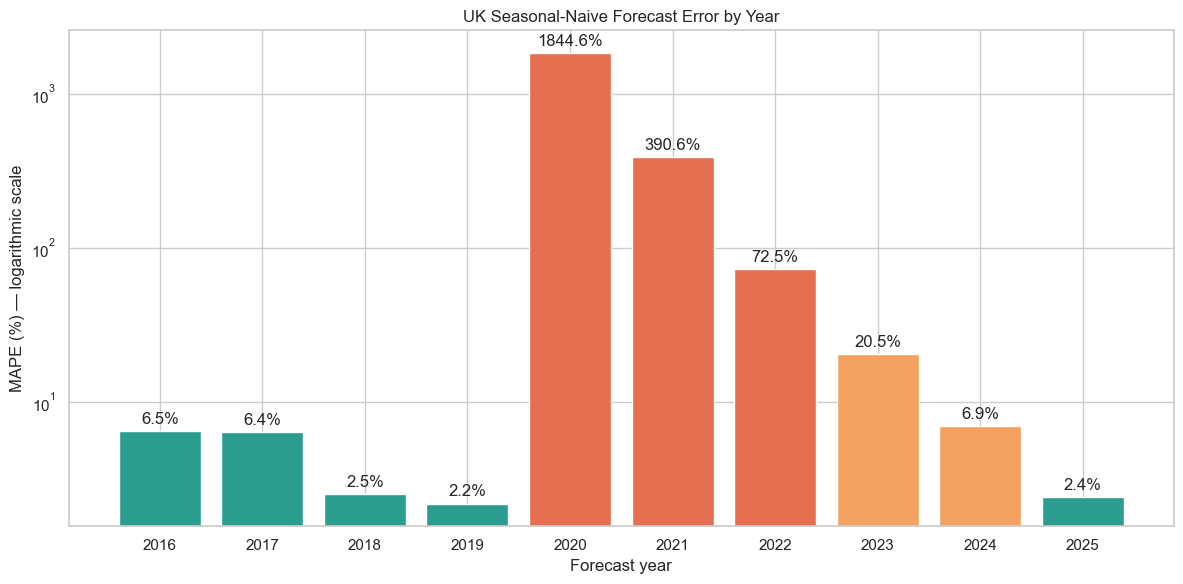

In [14]:
backtest_colours = [
    "#e76f51" if year in [2020, 2021, 2022]
    else "#f4a261" if year in [2023, 2024]
    else "#2a9d8f"
    for year in annual_backtest_metrics["year"]
]

plt.figure(figsize=(12, 6))

bars = plt.bar(
    annual_backtest_metrics["year"].astype(str),
    annual_backtest_metrics["MAPE"],
    color=backtest_colours,
)

plt.yscale("log")

plt.bar_label(
    bars,
    labels=[
        f"{value:.1f}%"
        for value in annual_backtest_metrics["MAPE"]
    ],
    padding=3,
)

plt.title(
    "UK Seasonal-Naive Forecast Error by Year"
)
plt.xlabel("Forecast year")
plt.ylabel("MAPE (%) — logarithmic scale")
plt.tight_layout()
plt.show()

## 10. Export forecasting results

The 2025 forecasts, model-performance metrics and annual backtest results are exported for use in the final model-evaluation and business-insights notebook.

In [15]:
forecast_results_2025 = (
    seasonal_naive_results.merge(
        holt_winters_results[
            [
                "period_date",
                "series_name",
                "holt_winters_prediction",
            ]
        ],
        on=["period_date", "series_name"],
        how="left",
        validate="one_to_one",
    )
)

forecast_results_2025["seasonal_naive_error"] = (
    forecast_results_2025[
        "seasonal_naive_prediction"
    ]
    - forecast_results_2025["actual_passengers"]
)

forecast_results_2025["holt_winters_error"] = (
    forecast_results_2025[
        "holt_winters_prediction"
    ]
    - forecast_results_2025["actual_passengers"]
)

processed_dir = project_root / "data" / "processed"
processed_dir.mkdir(parents=True, exist_ok=True)

forecast_output_path = (
    processed_dir / "forecast_results_2025.csv"
)

metrics_output_path = (
    processed_dir / "forecast_model_metrics.csv"
)

backtest_output_path = (
    processed_dir / "uk_annual_backtest_metrics.csv"
)

forecast_results_2025.to_csv(
    forecast_output_path,
    index=False,
)

model_metrics.to_csv(
    metrics_output_path,
    index=False,
)

annual_backtest_metrics.to_csv(
    backtest_output_path,
    index=False,
)

print("Exported files:")
print(f"  {forecast_output_path}")
print(f"  {metrics_output_path}")
print(f"  {backtest_output_path}")

Exported files:
  /Users/dafyddjones/projects/uk-aviation-demand-punctuality/data/processed/forecast_results_2025.csv
  /Users/dafyddjones/projects/uk-aviation-demand-punctuality/data/processed/forecast_model_metrics.csv
  /Users/dafyddjones/projects/uk-aviation-demand-punctuality/data/processed/uk_annual_backtest_metrics.csv


## 11. Conclusions

- All 11 passenger series contained 132 complete monthly observations from January 2015 to December 2025.
- Models were trained using data through December 2024 and evaluated against the unseen 2025 period.
- The seasonal-naive baseline was the best-performing model for 8 of the 11 series.
- Holt-Winters performed best for Manchester, Birmingham and Edinburgh, but produced substantial overforecasts for several other series.
- For the UK total, seasonal naive achieved a MAPE of 2.40%, compared with 12.51% for Holt-Winters.
- The national seasonal-naive forecast had an average absolute error of approximately 579,000 passengers per month during 2025.
- The COVID-19 disruption created a structural break that made historical seasonal patterns temporarily unreliable. National seasonal-naive MAPE increased to 1,844.55% in 2020.
- Forecast accuracy improved as the market stabilised, declining to 6.95% in 2024 and 2.40% in 2025.
- MAPE should be interpreted carefully when actual demand is close to zero because percentage errors can become exceptionally large.
- Model choice should be based on out-of-sample performance rather than complexity. Forecasts should also be supplemented with scenario analysis and management judgement when exceptional events occur.